# Task 2: Customer Segmentation Using Unsupervised Learning

## Objective
Cluster mall customers based on their annual income and spending habits, and suggest targeted marketing strategies for each identified customer segment.

## Dataset
The **Mall Customers Dataset** contains basic information about customers: CustomerID, Gender, Age, Annual Income (k$), and Spending Score (1-100).

## Workflow
1. **Exploratory Data Analysis (EDA)**: Explore distributions and correlations.
2. **K-Means Clustering**: Train K-Means models and find the optimal number of clusters using Elbow Method and Silhouette Analysis.
3. **Dimensionality Reduction**: Apply PCA and t-SNE to project features onto 2D/3D spaces for visualization.
4. **Strategic Recommendations**: Propose marketing actions for each segment based on their spending characteristics.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Load dataset
df = pd.read_csv('data/Mall_Customers.csv')
df = df.rename(columns={'Genre': 'Gender'})
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
# Check data info and summary stats
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [3]:
# Check for missing values
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


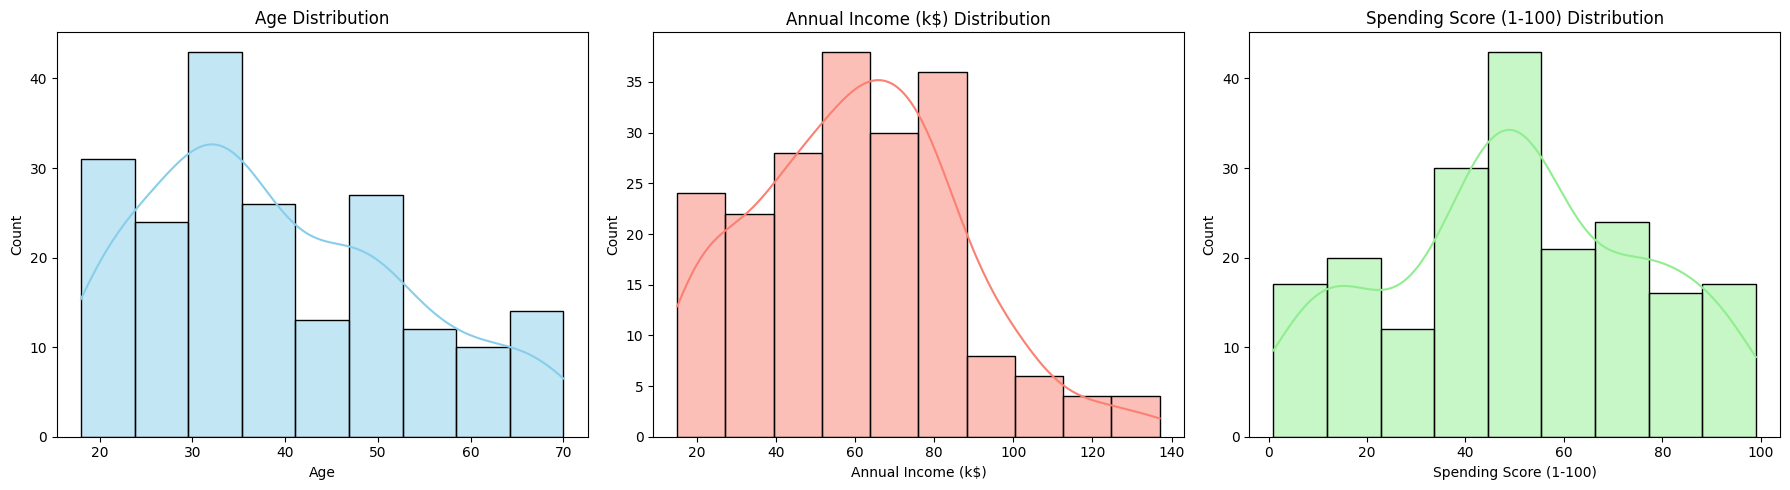

In [4]:
# Explore distributions of Age, Income, and Spending Score
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution')

sns.histplot(df['Annual Income (k$)'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Annual Income (k$) Distribution')

sns.histplot(df['Spending Score (1-100)'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Spending Score (1-100) Distribution')

plt.tight_layout()
plt.show()

C:\Users\Awad khan\AppData\Local\Temp\ipykernel_20108\3533144816.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='pastel')


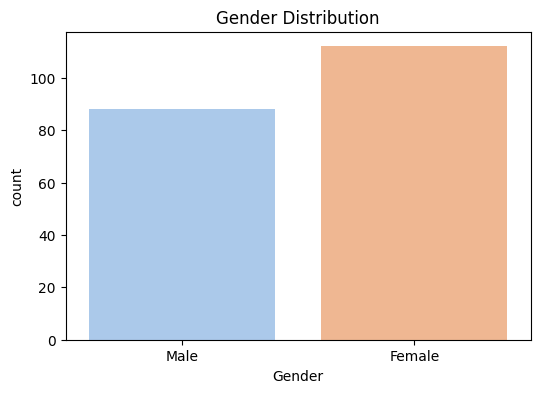

In [5]:
# Gender Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df, palette='pastel')
plt.title('Gender Distribution')
plt.show()

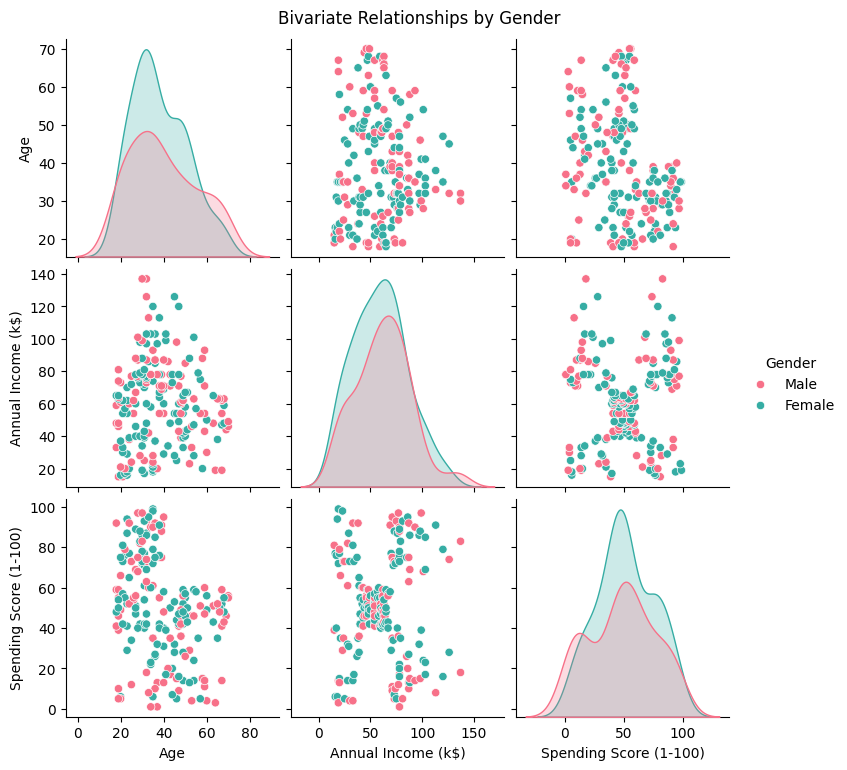

In [6]:
# Pairplot to see bivariate relationships
sns.pairplot(df.drop(columns=['CustomerID']), hue='Gender', palette='husl')
plt.suptitle('Bivariate Relationships by Gender', y=1.02)
plt.show()

## 2. Preprocessing & K-Means Clustering
We will scale features and run K-Means to segment customers based on `Annual Income (k$)` and `Spending Score (1-100)`.

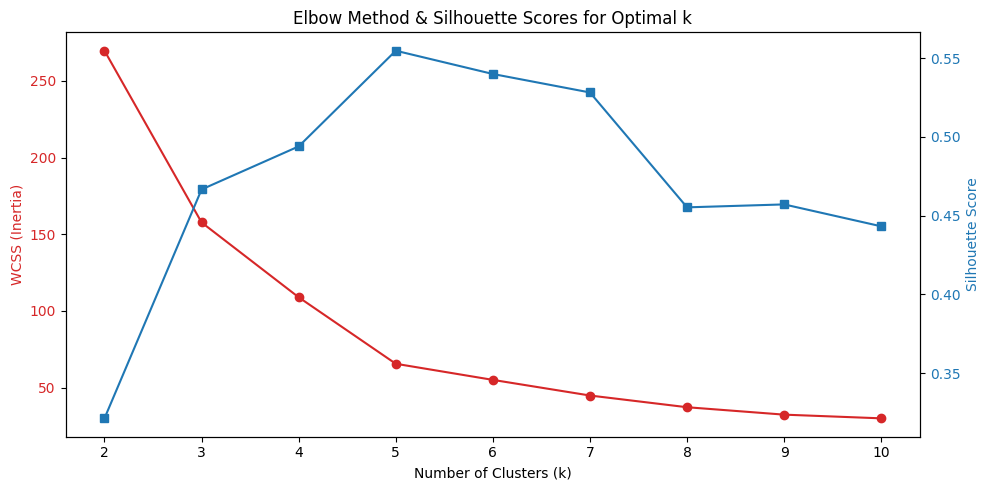

In [7]:
# Select features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate WCSS (Within-Cluster Sum of Square) for elbow method
wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow Curve and Silhouette Scores
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)', color=color)
ax1.plot(K_range, wcss, 'o-', color=color, label='WCSS')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K_range, silhouette_scores, 's-', color=color, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Elbow Method & Silhouette Scores for Optimal k')
fig.tight_layout()
plt.show()

Based on the WCSS elbow (sharp bend at k=5) and the highest silhouette score at k=5, the optimal number of clusters is **5**.

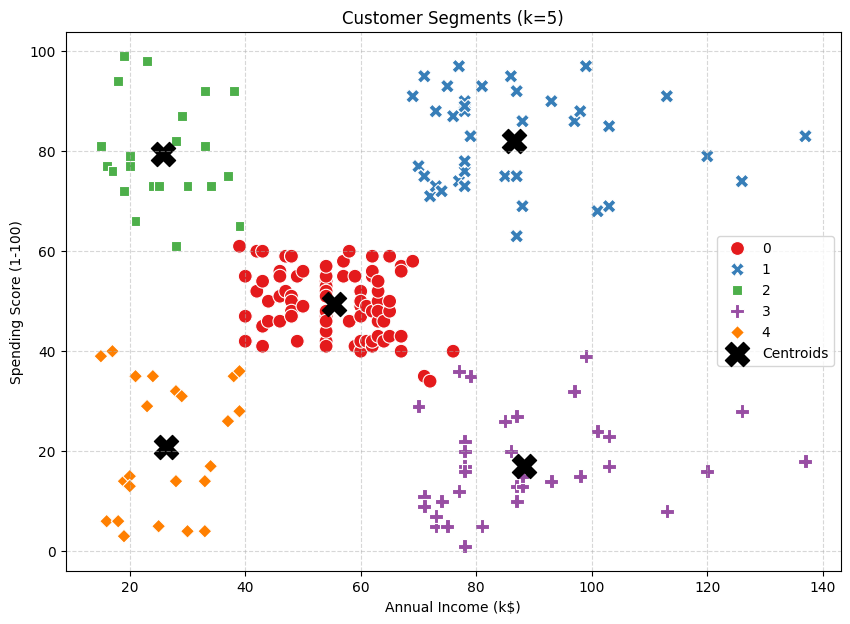

In [8]:
# Apply K-Means with k=5
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_transform(X_scaled).argmin(axis=1) # or kmeans.labels_
df['Cluster'] = kmeans.labels_

# Plot the 5 clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', 
                data=df, palette='Set1', s=100, style='Cluster')

# Plot centroids
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='black', marker='X', label='Centroids')

plt.title('Customer Segments (k=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 3. Dimensionality Reduction & Visualization
Let's cluster using all three numerical features: `Age`, `Annual Income (k$)`, and `Spending Score (1-100)`, then project the clusters onto 2D using PCA and t-SNE.

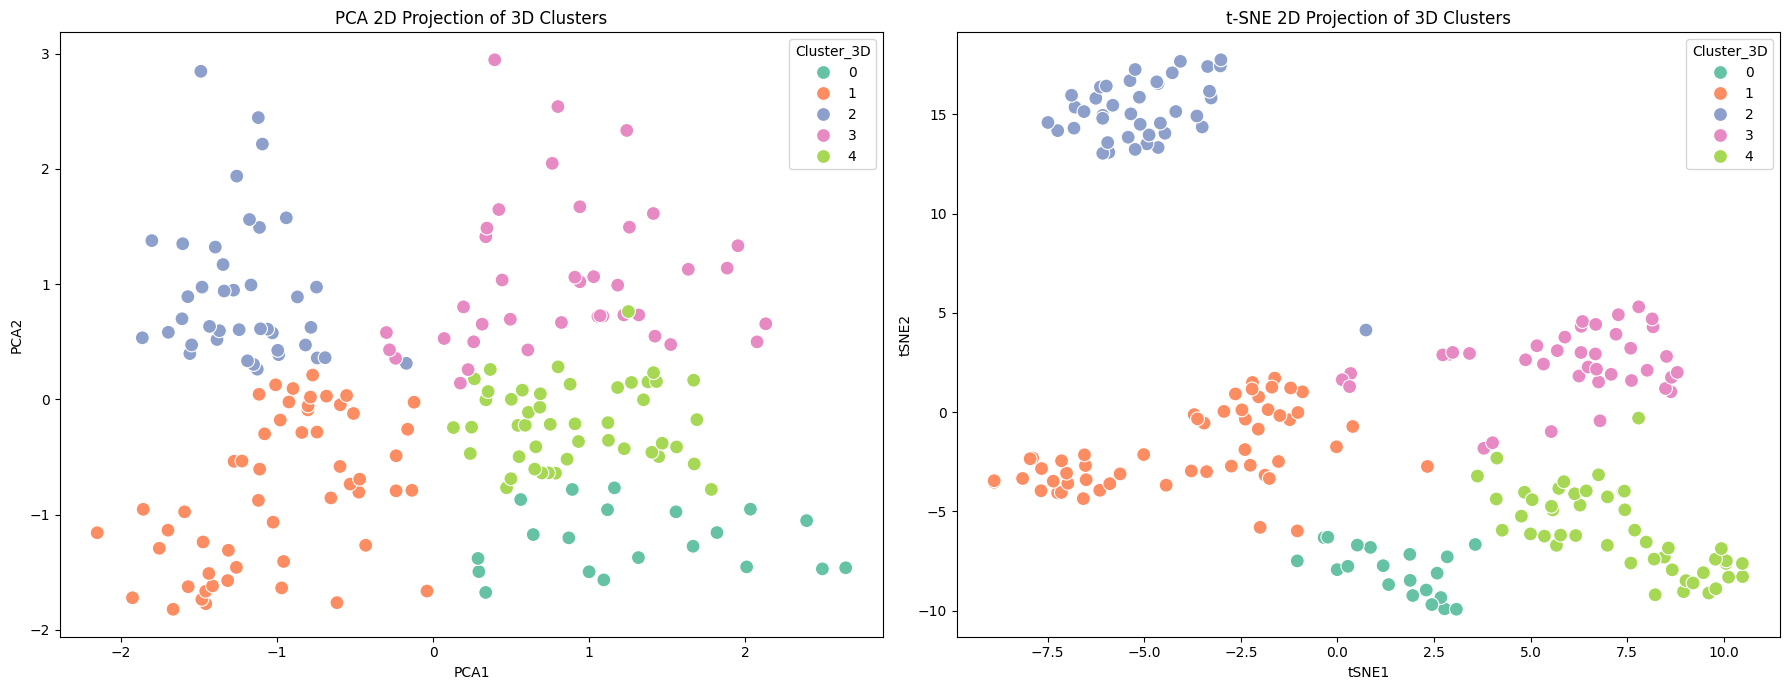

In [9]:
# Scale all three features
X_3d = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
X_3d_scaled = scaler.fit_transform(X_3d)

# Fit K-Means on 3D data
kmeans_3d = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
df['Cluster_3D'] = kmeans_3d.fit_predict(X_3d_scaled)

# 1. PCA Projection
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_3d_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# 2. t-SNE Projection
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_3d_scaled)
df['tSNE1'] = X_tsne[:, 0]
df['tSNE2'] = X_tsne[:, 1]

# Plot PCA & t-SNE visualizations
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster_3D', data=df, palette='Set2', s=100, ax=axes[0])
axes[0].set_title('PCA 2D Projection of 3D Clusters')

sns.scatterplot(x='tSNE1', y='tSNE2', hue='Cluster_3D', data=df, palette='Set2', s=100, ax=axes[1])
axes[1].set_title('t-SNE 2D Projection of 3D Clusters')

plt.tight_layout()
plt.show()

## 4. Segment Analysis & Marketing Strategies
Let's analyze the characteristics of each cluster and define specific marketing strategies.
We will label the 2D clusters as follows:
- **Cluster 0**: Low Income, High Spending (Spendthrifts)
- **Cluster 1**: High Income, High Spending (Target/Premium)
- **Cluster 2**: Low Income, Low Spending (Sensible)
- **Cluster 3**: High Income, Low Spending (Careful)
- **Cluster 4**: Average Income, Average Spending (Standard)

In [10]:
# Analyze cluster statistics
cluster_stats = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Gender': lambda x: (x == 'Female').mean() * 100
}).rename(columns={'Gender': 'Female %'})

# Name the clusters based on centroids
cluster_names = {
    0: 'Standard (Avg Income, Avg Spend)',
    1: 'Spendthrifts (Low Income, High Spend)',
    2: 'Target / Premium (High Income, High Spend)',
    3: 'Sensible (Low Income, Low Spend)',
    4: 'Careful (High Income, Low Spend)'
}
cluster_stats.index = cluster_stats.index.map(cluster_names)
cluster_stats

,Age,Annual Income (k$),Spending Score (1-100),Female %
Cluster,,,,
"Standard (Avg Income, Avg Spend)",42.716049,55.296296,49.518519,59.259259
"Spendthrifts (Low Income, High Spend)",32.692308,86.538462,82.128205,53.846154
"Target / Premium (High Income, High Spend)",25.272727,25.727273,79.363636,59.090909
"Sensible (Low Income, Low Spend)",41.114286,88.200000,17.114286,45.714286
"Careful (High Income, Low Spend)",45.217391,26.304348,20.913043,60.869565


### Tailored Marketing Strategies
1. **Target / Premium (High Income, High Spend)**:
   - *Strategy*: Introduce loyalty rewards, premium club memberships, previews of new luxury collections, and personalized concierges.
2. **Careful (High Income, Low Spend)**:
   - *Strategy*: Target with value-for-money high-end products, focus groups, quality assurance campaigns, and utility-based promotional messages.
3. **Spendthrifts (Low Income, High Spend)**:
   - *Strategy*: Send alerts for pop-up discount stores, flash sales, installment payment plans, and micro-influencer product recommendations.
4. **Sensible (Low Income, Low Spend)**:
   - *Strategy*: Highlight essential products, bulk deals, coupons, and basic cost-saving options.
5. **Standard (Avg Income, Avg Spend)**:
   - *Strategy*: Promote seasonal discount events, standard email marketing campaigns, and subscription services with generic offers.